In [123]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.v2 as T
from IPython.display import clear_output
from PIL import Image
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.optim import Optimizer

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [127]:
from torchmetrics.classification import BinaryF1Score

def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn, device: torch.device):
    model.train()

    total_loss = 0.0

    for x, y in tqdm(data_loader):
        x = x.to(device)
        y = y.to(device).float().unsqueeze(1)

        optimizer.zero_grad()

        output = model(x)
        loss = loss_fn(output, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)


In [146]:
@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, device: torch.device):
    model.eval()

    total_loss = 0.0
    f1_metric = BinaryF1Score().to(device)

    for x, y in tqdm(data_loader):
        x = x.to(device)
        y = y.to(device).float().unsqueeze(1)

        output = model(x)
        loss = loss_fn(output, y)

        total_loss += loss.item()

        probs = torch.sigmoid(output).squeeze(1)
        targets = y.squeeze(1).int()

        f1_metric.update(probs, targets)

    return total_loss / len(data_loader), f1_metric.compute().item()

In [147]:
def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    valid_f1: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' f1')

    plt.plot(valid_f1, label='Valid f1')
    plt.legend()

    plt.show()

In [148]:
def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    valid_f1_history =[]

    best_valid_f1 = -1.0

    for epoch in range(num_epochs):
        train_loss = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_f1 = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        valid_f1_history.append(valid_f1)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history, 
            valid_f1_history,
            title
        )
        if valid_f1 > best_valid_f1:
            best_valid_f1 = valid_f1
            torch.save(model.state_dict(), "checkpoints/best_model.pt")
            torch.save(optimizer.state_dict(), "checkpoints/best_optimizer.pt")
            print(f"best model epoch {epoch}")

In [176]:
@torch.inference_mode()
def predict_test(model, test_loader, device, threshold=0.5):
    model.eval()

    all_ids = []
    all_preds = []

    for x, ids in tqdm(test_loader):
        x = x.to(device)

        output = model(x)
        res = torch.sigmoid(output).squeeze(1)
        preds = (res > threshold).long()

        all_ids.extend(ids.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    submission = pd.DataFrame({
        "id": all_ids,
        "target_feature": all_preds
    })

    submission = submission.sort_values("id").reset_index(drop=True)
    submission.to_csv("submission.csv", index=False)

    return submission

In [150]:
import os
from PIL import Image
from torch.utils.data import DataLoader

def make_test_image_loader(
    folder_path,
    transform=None,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    return_ids=True,
):
    image_files = sorted(
        [f for f in os.listdir(folder_path) if f.lower().endswith(".jpg")],
        key=lambda x: int(os.path.splitext(x)[0])
    )

    data = []

    for filename in image_files:
        path = os.path.join(folder_path, filename)
        image = np.array(Image.open(path).convert("RGB"))

        if transform is not None:
            image = transform(image=image)["image"]

        if return_ids:
            img_id = int(os.path.splitext(filename)[0])
            data.append((image, img_id))
        else:
            data.append(image)

    return DataLoader(
        data,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=True
    )

In [151]:
from sklearn.model_selection import train_test_split


def make_train_valid_loaders(
    images_folder,
    labels_csv,
    train_transform=None,
    valid_transform=None,
    batch_size=32,
    valid_size=0.2,
    random_state=42,
    shuffle_train=True,
    num_workers=0
):
    df = pd.read_csv(labels_csv, header=None, names=["Id", "target_feature"])

    train_df, valid_df = train_test_split(
        df,
        test_size=valid_size,
        random_state=random_state,
        stratify=df["target_feature"]
    )

    train_items = [
        (os.path.join(images_folder, f"{int(row.Id)}.jpg"), int(row.target_feature))
        for row in train_df.itertuples(index=False)
    ]
    valid_items = [
        (os.path.join(images_folder, f"{int(row.Id)}.jpg"), int(row.target_feature))
        for row in valid_df.itertuples(index=False)
    ]

    def make_collate(transform):
        def collate_fn(batch):
            images = []
            labels = []

            for path, label in batch:
                image = np.array(Image.open(path).convert("RGB"))
                if transform is not None:
                    image = transform(image=image)["image"]
                images.append(image)
                labels.append(label)

            images = torch.stack(images)
            labels = torch.tensor(labels, dtype=torch.long)
            return images, labels
        return collate_fn

    train_loader = DataLoader(
        train_items,
        batch_size=batch_size,
        shuffle=shuffle_train,
        num_workers=num_workers,
        collate_fn=make_collate(train_transform),
        pin_memory=True
    )

    valid_loader = DataLoader(
        valid_items,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=make_collate(valid_transform),
        pin_memory=True
    )

    return train_loader, valid_loader

In [160]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.MedianBlur(blur_limit=(3, 3), p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5),
                std=(0.25, 0.25, 0.25)),
    ToTensorV2(),
])

test_transforms = A.Compose([
    A.Normalize(mean=(0.5, 0.5, 0.5),
                std=(0.25, 0.25, 0.25)),
    ToTensorV2(),
])

In [161]:
train_loader, valid_loader = make_train_valid_loaders(images_folder="/kaggle/input/datasets/hawwkps/dataset/dataset/train_images",labels_csv="/kaggle/input/datasets/hawwkps/dataset/dataset/train_solution.csv",train_transform=train_transforms,valid_transform=test_transforms,batch_size=128,valid_size=0.2,random_state=100,shuffle_train=True, num_workers=4)
test_loader = make_test_image_loader('/kaggle/input/datasets/hawwkps/dataset/dataset/test_images',transform=test_transforms, batch_size=128, shuffle= False,  num_workers=4)

In [162]:
import torch
import torch.nn as nn

class Baseline(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [163]:
df = pd.read_csv("/kaggle/input/datasets/hawwkps/dataset/dataset/train_solution.csv", header=None, names=["Id", "target_feature"])

num_pos = (df["target_feature"] == 1).sum()
num_neg = (df["target_feature"] == 0).sum()

pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)

In [164]:
model = Baseline().to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight = pos_weight).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay = 1e-4)

In [165]:
os.makedirs("checkpoints", exist_ok=True)

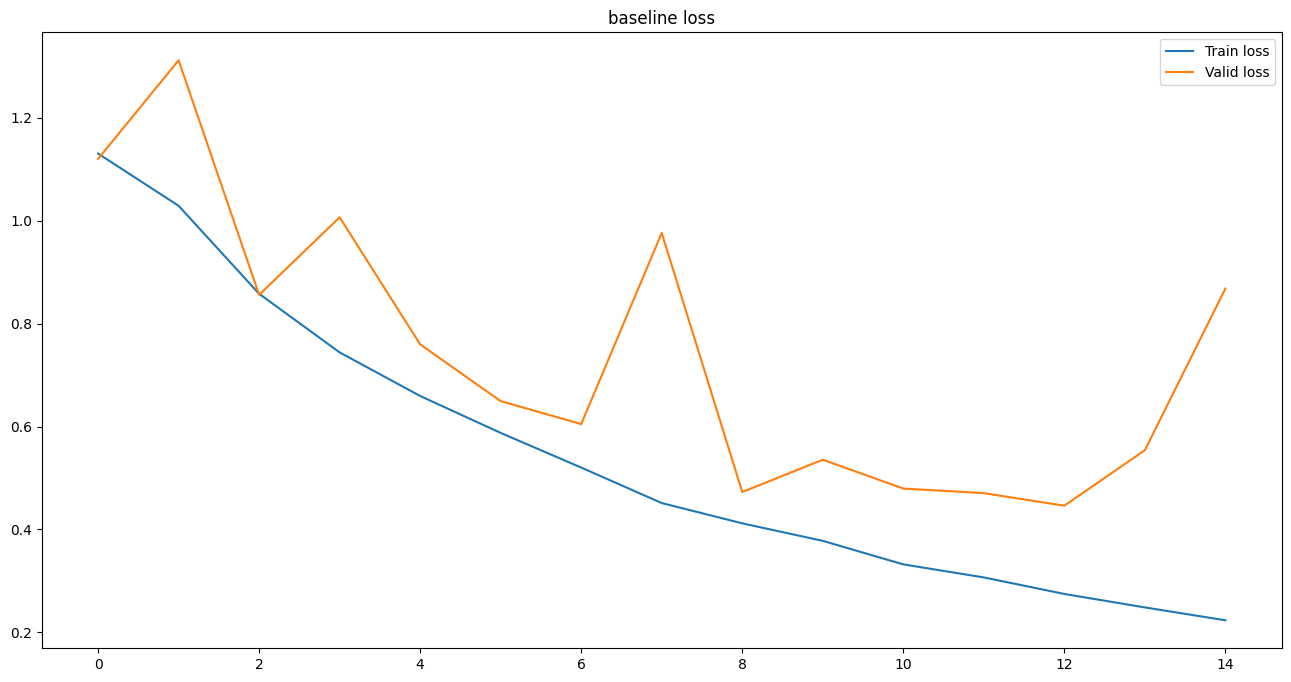

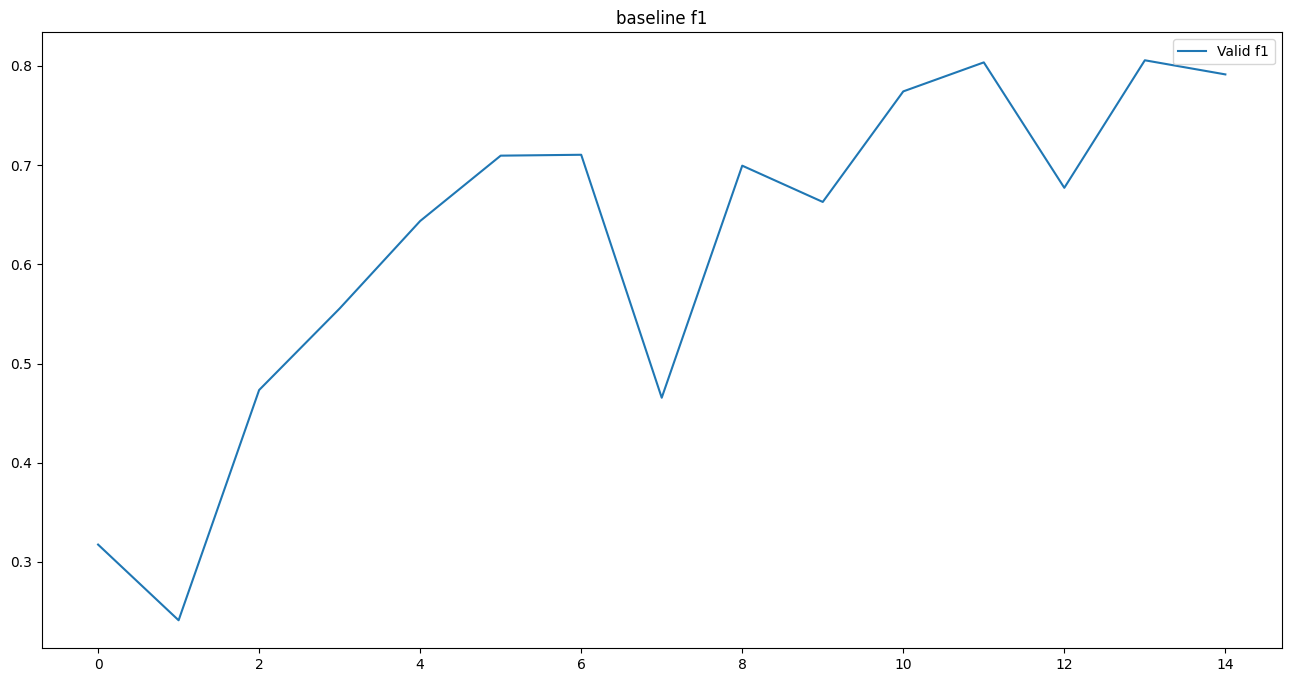

In [166]:
fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs=15, title="baseline")

In [167]:
torch.save(model.state_dict(), "baseline.pt")

In [177]:
submission = predict_test(model, test_loader, device)

100%|██████████| 79/79 [00:13<00:00,  5.75it/s]


In [181]:
# model.load_state_dict(torch.load("checkpoints/baseline.pt", map_location=device))
# submission = predict_test(model, test_loader, device, threshold=0.5)
# print(submission.head())

In [183]:
submission.head(10)

,id,target_feature
0,0,0
1,1,0
2,2,1
3,3,0
4,4,0
5,5,1
6,6,1
7,7,0
8,8,1
9,9,1
